Train: (2000, 28, 28)
Test : (1000, 28, 28)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4757 - loss: 1.6147 - val_accuracy: 0.8375 - val_loss: 0.5414
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8849 - loss: 0.3888 - val_accuracy: 0.8775 - val_loss: 0.4088
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9170 - loss: 0.2793 - val_accuracy: 0.9000 - val_loss: 0.3499
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9689 - loss: 0.1237 - val_accuracy: 0.9025 - val_loss: 0.3128
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9806 - loss: 0.0813 - val_accuracy: 0.9275 - val_loss: 0.2753
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9951 - loss: 0.0297 - val_accuracy: 0.9225 - val_loss: 0.3506
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9960 - loss: 0.0185 - val_accuracy: 0.9300 - val_loss: 0.3040
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9988 - loss: 0.0079 - val_accuracy: 0.9250 - val_loss: 0.

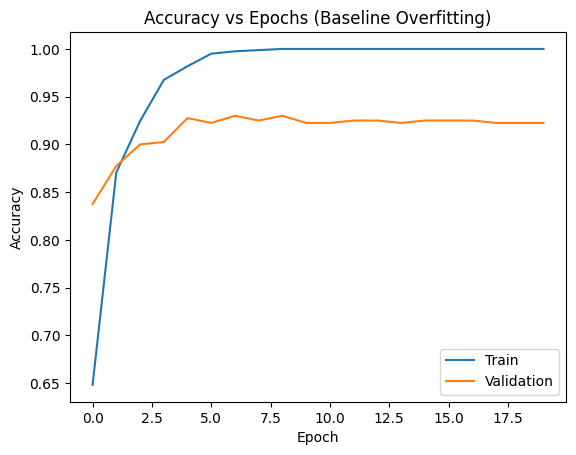

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# Small split to encourage overfitting
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=2000,
    test_size=1000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# Large model with no regularization (intentionally overfit)
model = keras.Sequential([
    layers.Dense(784, activation="relu", input_shape=(784,)),
    layers.Dense(784, activation="relu"),
    layers.Dense(784, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer='Adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train with validation tracking to show overfitting
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

# Plot accuracy curves (overfitting visible as gap)
plt.figure()
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title('Accuracy vs Epochs (Baseline Overfitting)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


#Mini batch Regularization

Train: (2000, 28, 28)
Test : (2000, 28, 28)
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6318 - loss: 1.1666
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9079 - loss: 0.2899
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9431 - loss: 0.1511
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9799 - loss: 0.0654
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9857 - loss: 0.0482
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9846 - loss: 0.0483
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9888 - loss: 0.0473
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9724 - loss: 0.0942
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9730 - loss: 0.0616
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9904 - loss: 0.0349
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9935 - loss: 0.0194
Epoch 12/20
63/63 ━

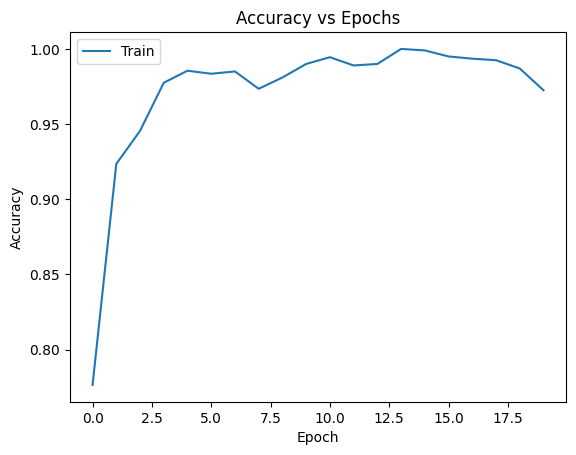

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers


# 1. Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all 70k samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# 2. Create 2000 / 2000 split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=2000,
    test_size=2000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# 3. Preprocess (CRITICAL)
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten for MLP
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# 4. Build Model
model = keras.Sequential([
    layers.Dense(784, activation="relu"),
    layers.Dense(784, activation="relu"),
    layers.Dense(784, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 5. Compile
model.compile(
    optimizer='Adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6. Train
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,       # This is the "Mini-Batch" part
)

# 7. Evaluate
train_loss, train_acc = model.evaluate(x_train, y_train)

print("\nTrain Accuracy:", train_acc)

# 7. Evaluate
train_loss, train_acc = model.evaluate(x_train, y_train)

print("\nTrain Accuracy:", train_acc)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['accuracy'])
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

#L2 Regularization

Train: (20000, 28, 28)
Test : (10000, 28, 28)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7787 - loss: 2.3788 - val_accuracy: 0.9425 - val_loss: 1.0645
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9527 - loss: 0.9149 - val_accuracy: 0.9507 - val_loss: 0.6719
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.9637 - loss: 0.5785 - val_accuracy: 0.9442 - val_loss: 0.5184
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9698 - loss: 0.4177 - val_accuracy: 0.9592 - val_loss: 0.3988
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9730 - loss: 0.3347 - val_accuracy: 0.9615 - val_loss: 0.3433
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9794 - loss: 0.2784 - val_accuracy: 0.9590 - val_loss: 0.3246
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9782 - loss: 0.2477 - val_accuracy: 0.9607 - val_loss: 0.3022
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9788 - loss: 0.2397 - val_accuracy: 0

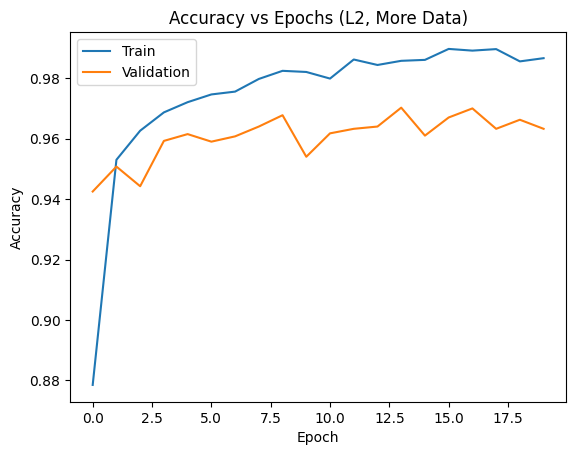

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# Use more samples now
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=20000,
    test_size=10000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# L2 regularizer
l2_reg = regularizers.l2(0.001)

# Build L2 model
model = keras.Sequential([
    layers.Dense(784, activation="relu",
                 kernel_regularizer=l2_reg,
                 input_shape=(784,)),
    layers.Dense(784, activation="relu",
                 kernel_regularizer=l2_reg),
    layers.Dense(784, activation="relu",
                 kernel_regularizer=l2_reg),
    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer='Adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

# Plot curves
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (L2, More Data)")
plt.legend()
plt.show()


#Dropout Regularization

Train: (20000, 28, 28)
Test : (10000, 28, 28)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7576 - loss: 0.7619 - val_accuracy: 0.9400 - val_loss: 0.1983
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9441 - loss: 0.1826 - val_accuracy: 0.9542 - val_loss: 0.1471
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.9557 - loss: 0.1326 - val_accuracy: 0.9647 - val_loss: 0.1249
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9678 - loss: 0.0978 - val_accuracy: 0.9620 - val_loss: 0.1186
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9798 - loss: 0.0609 - val_accuracy: 0.9500 - val_loss: 0.1680
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9786 - loss: 0.0621 - val_accuracy: 0.9668 - val_loss: 0.1226
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9832 - loss: 0.0563 - val_accuracy: 0.9735 - val_loss: 0.1017
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9860 - loss: 0.0414 - val_accuracy: 0.97

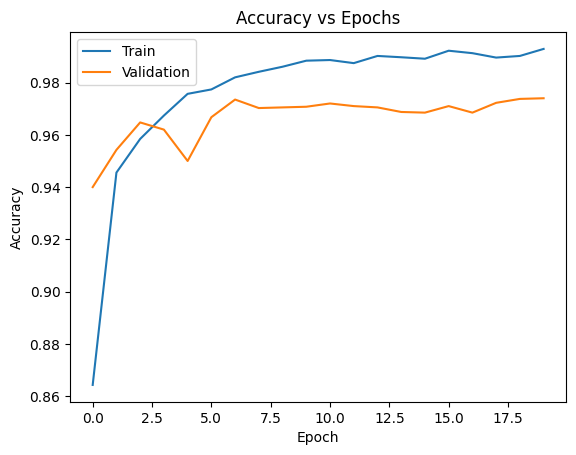

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# Create small train/test split (to show overfitting easily)
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=20000,
    test_size=10000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten for MLP
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# Build Dropout Model
model = keras.Sequential([
    layers.Dense(784, activation="relu", input_shape=(784,)),
    layers.Dropout(0.3),

    layers.Dense(784, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(784, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer='Adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train with validation split (needed for overfitting study)
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=128
)

# Evaluate on train and test
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

# Plot accuracy curves
plt.figure()
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


#Batch Normalization

Train: (20000, 28, 28)
Test : (10000, 28, 28)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.8531 - loss: 0.4650 - val_accuracy: 0.9405 - val_loss: 0.2262
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9733 - loss: 0.0817 - val_accuracy: 0.9553 - val_loss: 0.1442
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9870 - loss: 0.0417 - val_accuracy: 0.9532 - val_loss: 0.1670
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9881 - loss: 0.0397 - val_accuracy: 0.9570 - val_loss: 0.1574
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9872 - loss: 0.0348 - val_accuracy: 0.9575 - val_loss: 0.1665
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9927 - loss: 0.0220 - val_accuracy: 0.9657 - val_loss: 0.1220
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9947 - loss: 0.0172 - val_accuracy: 0.9622 - val_loss: 0.1468
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9944 - loss: 0.0170 - val_accuracy: 0.

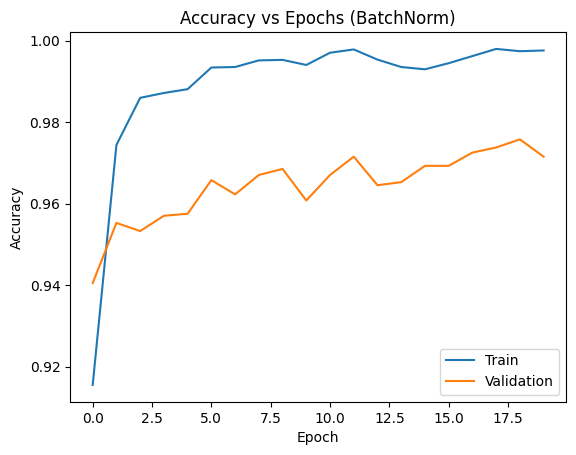

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load MNIST
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

# Combine all samples
X = np.concatenate((x_train_orig, x_test_orig))
y = np.concatenate((y_train_orig, y_test_orig))

# Create 2000 / 2000 split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=20000,
    test_size=10000,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test :", x_test.shape)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten for MLP
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# Build Batch Normalization model
model = keras.Sequential([
    layers.Dense(784, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Dense(784),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Dense(784),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer='Adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train with validation split for overfitting comparison
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# Evaluate on train and test
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

# Plot accuracy curves
plt.figure()
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title('Accuracy vs Epochs (BatchNorm)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
